# Diabetes Prediction — Model Building & Evaluation

This notebook trains and compares **7 classification models** on the cleaned diabetes dataset, then tunes the best performer.

**Models**: Logistic Regression, Decision Tree, Random Forest, KNN, SVM, Gradient Boosting, Naive Bayes

## 1. Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

from utils import evaluate_model, plot_confusion_matrix, plot_roc_curves, cross_validate_model, compare_models

sns.set_style("whitegrid")
%matplotlib inline


## 2. Load Cleaned Data

In [ ]:
df = pd.read_csv("data/diabetes_cleaned.csv")
print(f"Dataset shape: {df.shape}")
df.head()


Dataset shape: (768, 22)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,BMI_Category_Normal,...,AgeGroup_30s,AgeGroup_40s,AgeGroup_50s,AgeGroup_60+,Glucose_Category_Prediabetes,Glucose_Category_Diabetes,Insulin_Category_Normal,Insulin_Category_High,BP_Category_High_Stage1,BP_Category_High_Stage2
0,6,148.0,72.0,35.0,125.0,33.6,0.627,50,1,False,...,False,True,False,False,False,True,True,False,False,False
1,1,85.0,66.0,29.0,125.0,26.6,0.351,31,0,False,...,True,False,False,False,False,False,True,False,False,False
2,8,183.0,64.0,29.0,125.0,23.3,0.672,32,1,True,...,True,False,False,False,False,True,True,False,False,False
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0,False,...,False,False,False,False,False,False,True,False,False,False
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1,False,...,True,False,False,False,False,True,False,True,False,False


## 3. Prepare Features & Target

In [ ]:
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

print(f"Features: {X.shape[1]}")
print(f"Samples : {X.shape[0]}")
print(f"\nTarget distribution:")
print(y.value_counts())


Features: 21
Samples : 768

Target distribution:
Outcome
0    500
1    268
Name: count, dtype: int64


In [ ]:
# Train/Test Split (80/20, stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape[0]} samples")
print(f"Test : {X_test.shape[0]} samples")
print(f"\nTrain target distribution: {dict(y_train.value_counts())}")
print(f"Test target distribution : {dict(y_test.value_counts())}")


Train: 614 samples
Test : 154 samples

Train target distribution: {0: np.int64(400), 1: np.int64(214)}
Test target distribution : {0: np.int64(100), 1: np.int64(54)}


In [ ]:
# Feature scaling (needed for KNN, SVM, Logistic Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


## 4. Train Models

We train 7 classifiers and collect their results for comparison.

In [ ]:
results = []
trained_models = {}  # Store for ROC curves later


### 4.1 Logistic Regression


  Logistic Regression
  Accuracy    : 0.7468
  Precision   : 0.6596
  Recall      : 0.5741
  F1 Score    : 0.6139


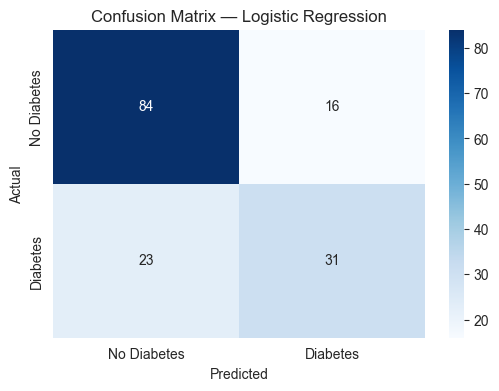

In [ ]:
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

metrics = evaluate_model("Logistic Regression", y_test, y_pred_lr)
results.append(metrics)
trained_models["Logistic Regression"] = lr

plot_confusion_matrix(y_test, y_pred_lr, "Logistic Regression")
plt.show()


### 4.2 Decision Tree


  Decision Tree
  Accuracy    : 0.7403
  Precision   : 0.6061
  Recall      : 0.7407
  F1 Score    : 0.6667


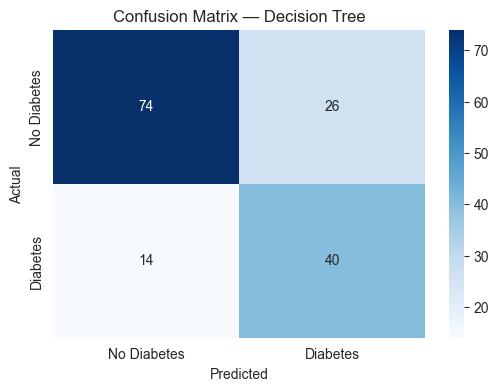

In [ ]:
dt = DecisionTreeClassifier(max_depth=5, random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

metrics = evaluate_model("Decision Tree", y_test, y_pred_dt)
results.append(metrics)
trained_models["Decision Tree"] = dt

plot_confusion_matrix(y_test, y_pred_dt, "Decision Tree")
plt.show()


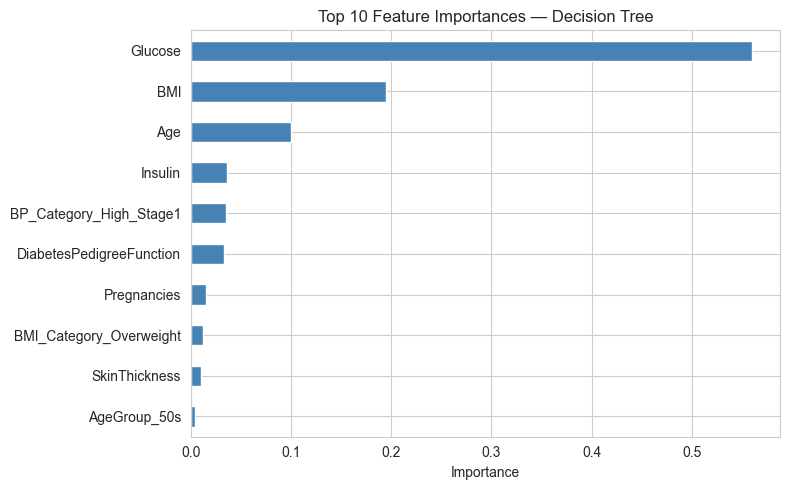

In [ ]:
# Feature importance from Decision Tree
feat_imp = pd.Series(dt.feature_importances_, index=X.columns).sort_values(ascending=True)
feat_imp.tail(10).plot(kind="barh", color="steelblue", figsize=(8, 5))
plt.title("Top 10 Feature Importances — Decision Tree")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()


### 4.3 Random Forest


  Random Forest
  Accuracy    : 0.7727
  Precision   : 0.7021
  Recall      : 0.6111
  F1 Score    : 0.6535


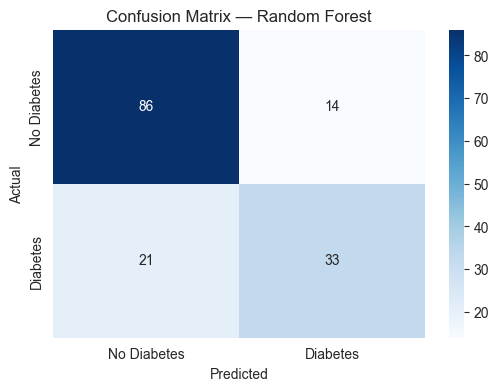

In [ ]:
rf = RandomForestClassifier(n_estimators=100, max_depth=7, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

metrics = evaluate_model("Random Forest", y_test, y_pred_rf)
results.append(metrics)
trained_models["Random Forest"] = rf

plot_confusion_matrix(y_test, y_pred_rf, "Random Forest")
plt.show()


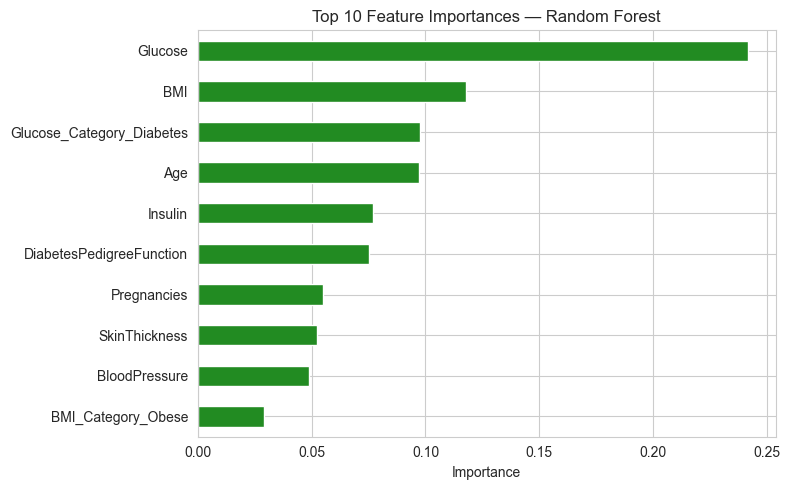

In [ ]:
# Feature importance from Random Forest
feat_imp_rf = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=True)
feat_imp_rf.tail(10).plot(kind="barh", color="forestgreen", figsize=(8, 5))
plt.title("Top 10 Feature Importances — Random Forest")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()


### 4.4 K-Nearest Neighbors

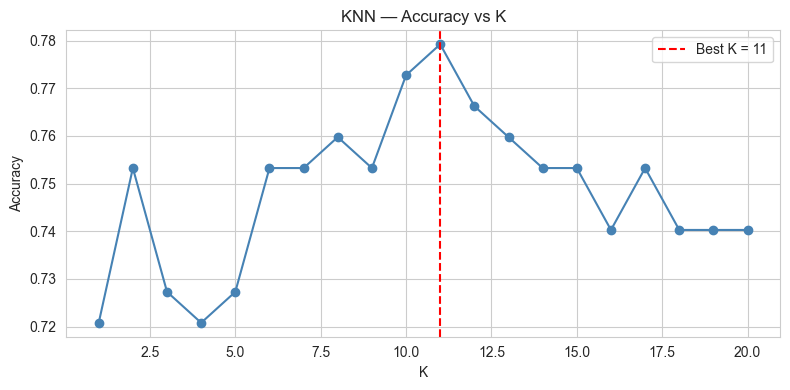

In [ ]:
# Find optimal K
k_range = range(1, 21)
k_scores = []
for k in k_range:
    knn_temp = KNeighborsClassifier(n_neighbors=k)
    knn_temp.fit(X_train_scaled, y_train)
    k_scores.append(knn_temp.score(X_test_scaled, y_test))

best_k = list(k_range)[np.argmax(k_scores)]

plt.figure(figsize=(8, 4))
plt.plot(k_range, k_scores, marker="o", color="steelblue")
plt.axvline(best_k, color="red", linestyle="--", label=f"Best K = {best_k}")
plt.xlabel("K")
plt.ylabel("Accuracy")
plt.title("KNN — Accuracy vs K")
plt.legend()
plt.tight_layout()
plt.show()



  KNN
  Accuracy    : 0.7792
  Precision   : 0.6923
  Recall      : 0.6667
  F1 Score    : 0.6792


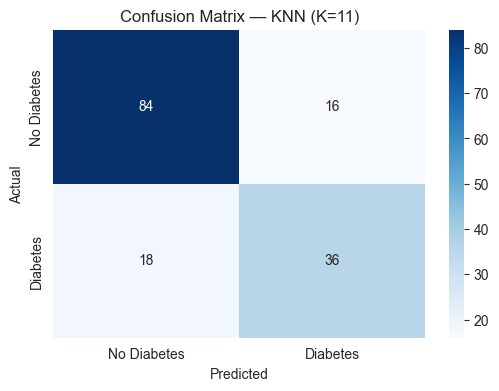

In [ ]:
knn = KNeighborsClassifier(n_neighbors=best_k)
knn.fit(X_train_scaled, y_train)
y_pred_knn = knn.predict(X_test_scaled)

metrics = evaluate_model("KNN", y_test, y_pred_knn)
results.append(metrics)
trained_models["KNN"] = knn

plot_confusion_matrix(y_test, y_pred_knn, f"KNN (K={best_k})")
plt.show()


### 4.5 Support Vector Machine


  SVM
  Accuracy    : 0.7532
  Precision   : 0.6481
  Recall      : 0.6481
  F1 Score    : 0.6481


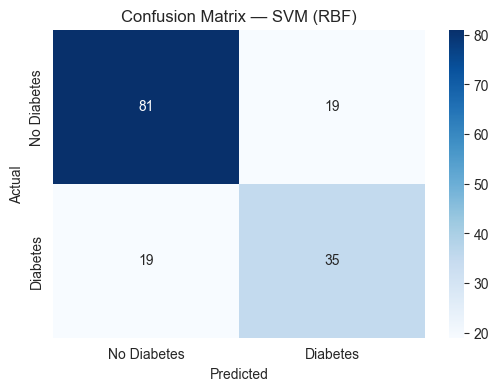

In [ ]:
svm = SVC(kernel="rbf", probability=True, random_state=42)
svm.fit(X_train_scaled, y_train)
y_pred_svm = svm.predict(X_test_scaled)

metrics = evaluate_model("SVM", y_test, y_pred_svm)
results.append(metrics)
trained_models["SVM"] = svm

plot_confusion_matrix(y_test, y_pred_svm, "SVM (RBF)")
plt.show()


### 4.6 Gradient Boosting


  Gradient Boosting
  Accuracy    : 0.7532
  Precision   : 0.6667
  Recall      : 0.5926
  F1 Score    : 0.6275


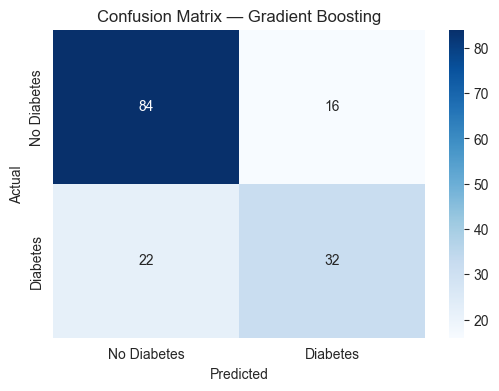

In [ ]:
gb = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)

metrics = evaluate_model("Gradient Boosting", y_test, y_pred_gb)
results.append(metrics)
trained_models["Gradient Boosting"] = gb

plot_confusion_matrix(y_test, y_pred_gb, "Gradient Boosting")
plt.show()


### 4.7 Naive Bayes


  Naive Bayes
  Accuracy    : 0.7013
  Precision   : 0.5606
  Recall      : 0.6852
  F1 Score    : 0.6167


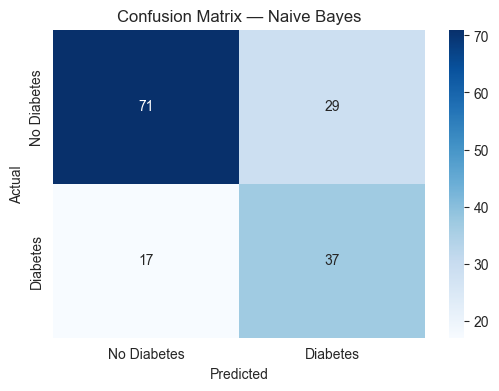

In [ ]:
nb = GaussianNB()
nb.fit(X_train, y_train)
y_pred_nb = nb.predict(X_test)

metrics = evaluate_model("Naive Bayes", y_test, y_pred_nb)
results.append(metrics)
trained_models["Naive Bayes"] = nb

plot_confusion_matrix(y_test, y_pred_nb, "Naive Bayes")
plt.show()


## 5. Model Comparison

In [ ]:
df_results = compare_models(results)
df_results


,Model,Accuracy,Precision,Recall,F1 Score
0,KNN,0.779221,0.692308,0.666667,0.679245
1,Decision Tree,0.740260,0.606061,0.740741,0.666667
2,Random Forest,0.772727,0.702128,0.611111,0.653465
3,SVM,0.753247,0.648148,0.648148,0.648148
4,Gradient Boosting,0.753247,0.666667,0.592593,0.627451
5,Naive Bayes,0.701299,0.560606,0.685185,0.616667
6,Logistic Regression,0.746753,0.659574,0.574074,0.613861


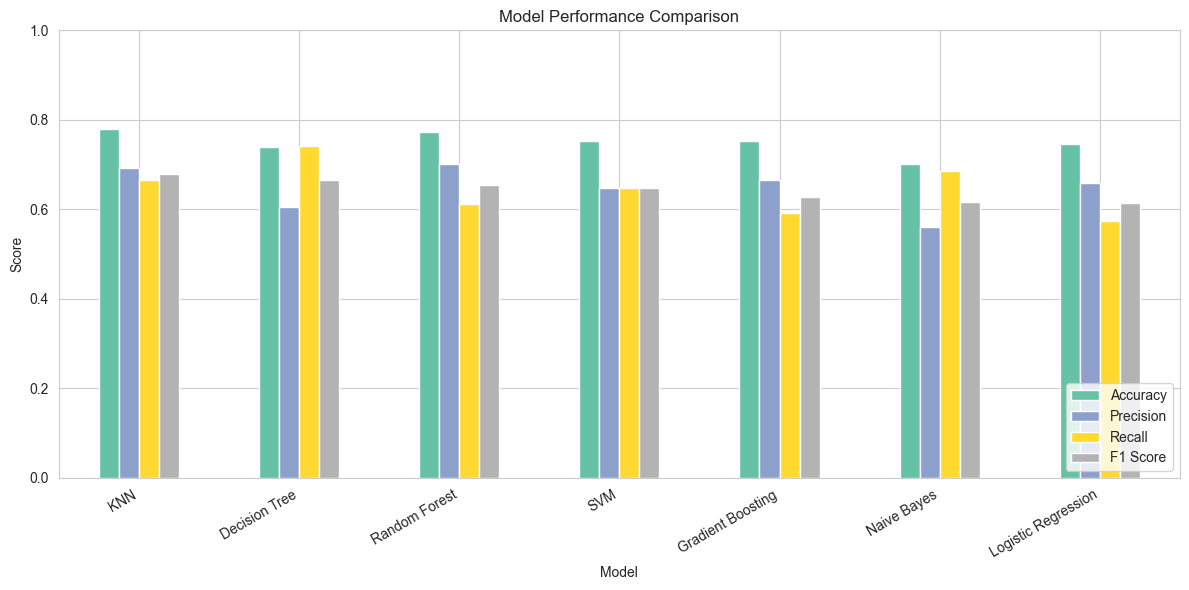

In [ ]:
# Bar chart comparison
fig, ax = plt.subplots(figsize=(12, 6))
df_results.set_index("Model")[["Accuracy", "Precision", "Recall", "F1 Score"]].plot(
    kind="bar", ax=ax, colormap="Set2"
)
ax.set_title("Model Performance Comparison")
ax.set_ylabel("Score")
ax.set_ylim(0, 1)
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()


## 6. Cross-Validation

In [ ]:
cv_results = {}

models_for_cv = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(max_depth=5, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=7, random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=best_k),
    "SVM": SVC(kernel="rbf", probability=True, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42),
    "Naive Bayes": GaussianNB(),
}

# Use scaled data for models that need it
scale_needed = {"Logistic Regression", "KNN", "SVM"}

for name, model in models_for_cv.items():
    print(f"\n{name}:")
    X_cv = X_train_scaled if name in scale_needed else X_train
    scores = cross_validate_model(model, X_cv, y_train, cv=5)
    cv_results[name] = scores



Logistic Regression:
  CV F1 Scores : [0.5823 0.6667 0.625  0.6667 0.7027]
  Mean F1      : 0.6487 (+/- 0.0413)

Decision Tree:
  CV F1 Scores : [0.6118 0.507  0.5205 0.6053 0.6222]
  Mean F1      : 0.5734 (+/- 0.0491)

Random Forest:
  CV F1 Scores : [0.6098 0.6914 0.5823 0.5833 0.6582]
  Mean F1      : 0.6250 (+/- 0.0431)

KNN:
  CV F1 Scores : [0.5789 0.6444 0.642  0.56   0.6914]
  Mean F1      : 0.6233 (+/- 0.0478)

SVM:
  CV F1 Scores : [0.5263 0.6824 0.6173 0.5634 0.641 ]
  Mean F1      : 0.6061 (+/- 0.0554)

Gradient Boosting:
  CV F1 Scores : [0.5926 0.7209 0.6279 0.5714 0.6667]
  Mean F1      : 0.6359 (+/- 0.0534)

Naive Bayes:
  CV F1 Scores : [0.6067 0.6522 0.6526 0.6279 0.5977]
  Mean F1      : 0.6274 (+/- 0.0226)


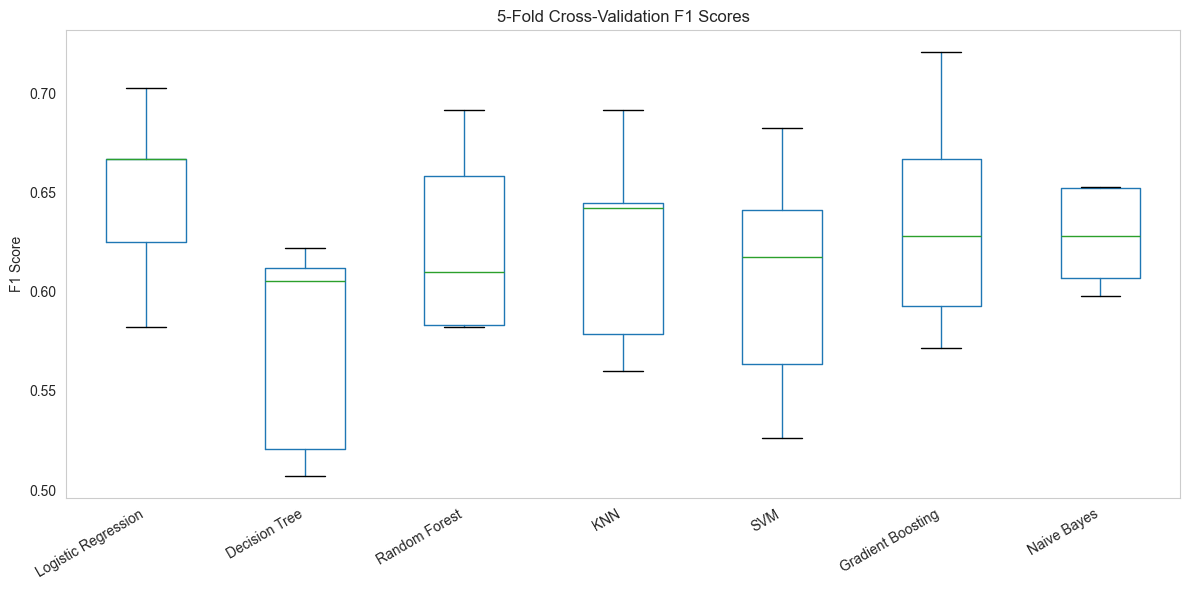

In [ ]:
# Box plot of CV scores
fig, ax = plt.subplots(figsize=(12, 6))
cv_df = pd.DataFrame(cv_results)
cv_df.boxplot(ax=ax, grid=False)
ax.set_title("5-Fold Cross-Validation F1 Scores")
ax.set_ylabel("F1 Score")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


## 7. ROC Curves

/Users/taimour/conda/envs/personal/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/Users/taimour/conda/envs/personal/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/Users/taimour/conda/envs/personal/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but GradientBoostingClassifier was fitted with feature names
  warnings.warn(
/Users/taimour/conda/envs/personal/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but GaussianNB was fitted with feature names
  warnings.warn(


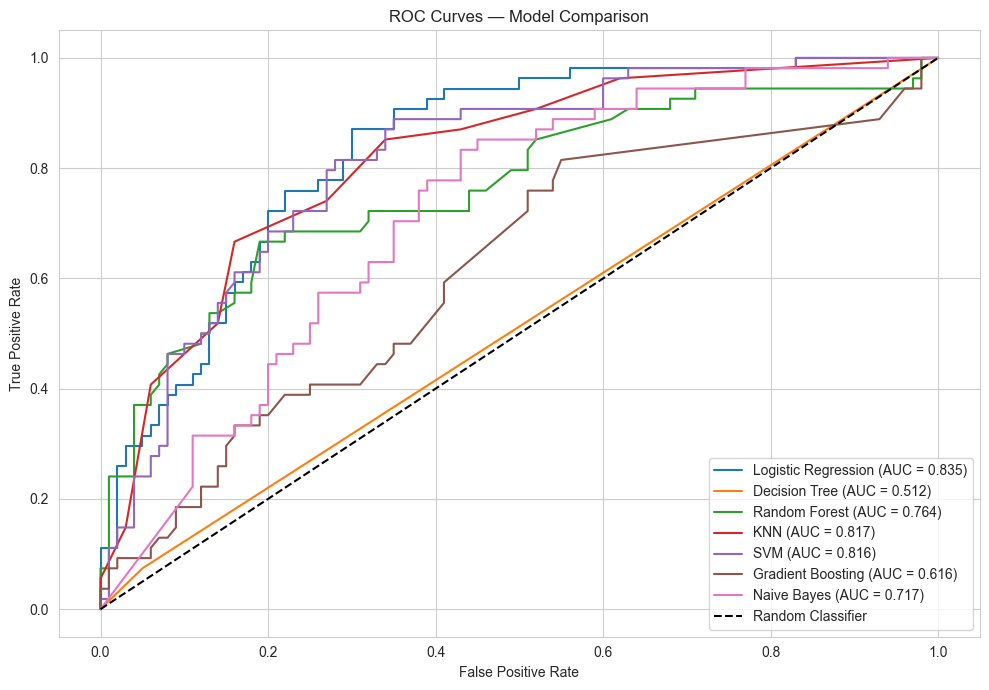

In [ ]:
# Models that need scaled data vs unscaled
# For ROC, we need to handle scaled/unscaled separately
# Since plot_roc_curves uses X_test directly, we pass scaled for models that need it
# For simplicity, we'll plot ROC curves using scaled data (tree models still work fine with it)
plot_roc_curves(trained_models, X_test_scaled, y_test)


## 8. Hyperparameter Tuning — Random Forest

In [ ]:
param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [3, 5, 7, 10],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1,
    verbose=1,
)

grid_search.fit(X_train, y_train)

print(f"\nBest Parameters: {grid_search.best_params_}")
print(f"Best CV F1 Score: {grid_search.best_score_:.4f}")


Fitting 5 folds for each of 108 candidates, totalling 540 fits


/Users/taimour/conda/envs/personal/lib/python3.12/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/Users/taimour/conda/envs/personal/lib/python3.12/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/Users/taimour/conda/envs/personal/lib/python3.12/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from usi


Best Parameters: {'max_depth': 7, 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 50}
Best CV F1 Score: 0.6653



  Random Forest (Tuned)
  Accuracy    : 0.7662
  Precision   : 0.6957
  Recall      : 0.5926
  F1 Score    : 0.6400


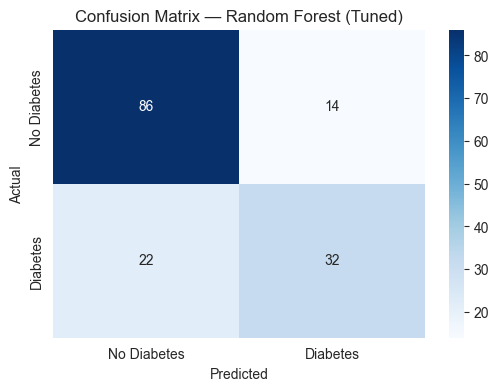

In [ ]:
# Evaluate tuned model
best_rf = grid_search.best_estimator_
y_pred_tuned = best_rf.predict(X_test)

metrics_tuned = evaluate_model("Random Forest (Tuned)", y_test, y_pred_tuned)

plot_confusion_matrix(y_test, y_pred_tuned, "Random Forest (Tuned)")
plt.show()


## 9. Feature Importance — Tuned Model

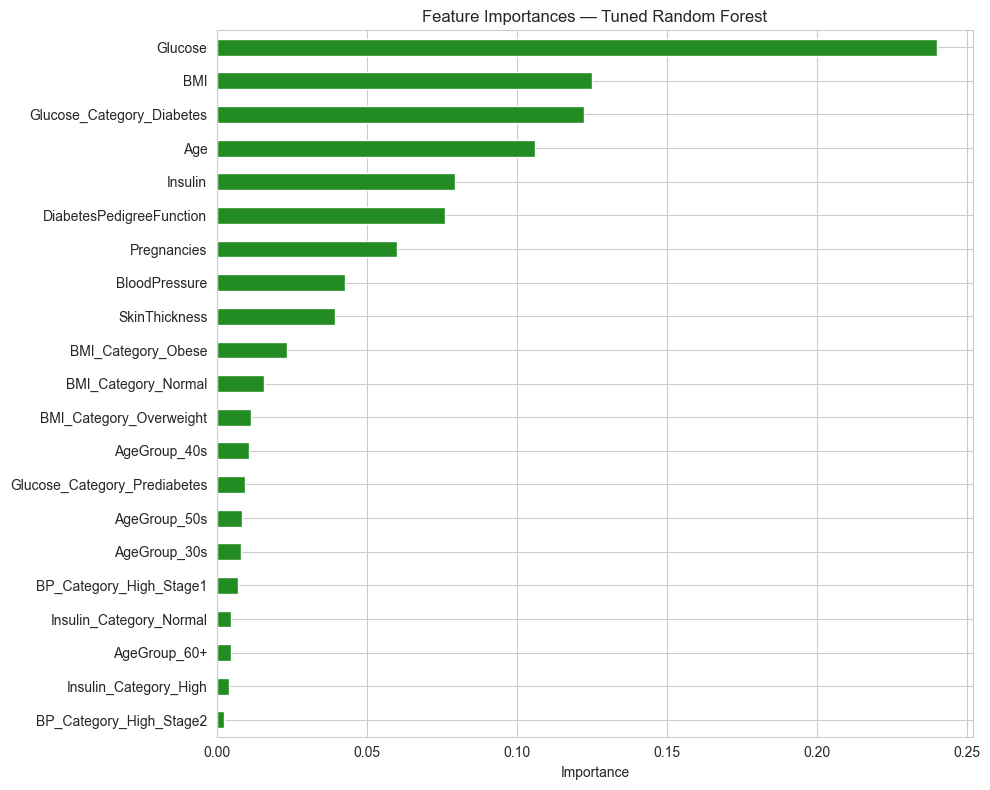

In [ ]:
feat_imp_tuned = pd.Series(best_rf.feature_importances_, index=X.columns).sort_values(ascending=True)

plt.figure(figsize=(10, 8))
feat_imp_tuned.plot(kind="barh", color="forestgreen")
plt.title("Feature Importances — Tuned Random Forest")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()


## 10. Prediction Example

In [ ]:
# Example: predict for a new patient
sample = X_test.iloc[[0]]

prediction = best_rf.predict(sample)[0]
probability = best_rf.predict_proba(sample)[0]

print("Sample Patient Features:")
for col, val in sample.iloc[0].items():
    print(f"  {col}: {val}")

print(f"\nPrediction: {'Diabetic' if prediction == 1 else 'Not Diabetic'}")
print(f"Confidence: {probability[prediction]:.1%}")
print(f"  P(No Diabetes) = {probability[0]:.3f}")
print(f"  P(Diabetes)    = {probability[1]:.3f}")


Sample Patient Features:
  Pregnancies: 7
  Glucose: 159.0
  BloodPressure: 64.0
  SkinThickness: 29.0
  Insulin: 125.0
  BMI: 27.4
  DiabetesPedigreeFunction: 0.294
  Age: 40
  BMI_Category_Normal: False
  BMI_Category_Overweight: True
  BMI_Category_Obese: False
  AgeGroup_30s: True
  AgeGroup_40s: False
  AgeGroup_50s: False
  AgeGroup_60+: False
  Glucose_Category_Prediabetes: False
  Glucose_Category_Diabetes: True
  Insulin_Category_Normal: True
  Insulin_Category_High: False
  BP_Category_High_Stage1: False
  BP_Category_High_Stage2: False

Prediction: Diabetic
Confidence: 57.4%
  P(No Diabetes) = 0.426
  P(Diabetes)    = 0.574


## 11. Final Summary

### Model Comparison (including tuned)

In [ ]:
# Add tuned model to results
all_results = results + [metrics_tuned]
df_final = compare_models(all_results)
df_final


,Model,Accuracy,Precision,Recall,F1 Score
0,KNN,0.779221,0.692308,0.666667,0.679245
1,Decision Tree,0.740260,0.606061,0.740741,0.666667
2,Random Forest,0.772727,0.702128,0.611111,0.653465
3,SVM,0.753247,0.648148,0.648148,0.648148
4,Random Forest (Tuned),0.766234,0.695652,0.592593,0.640000
5,Gradient Boosting,0.753247,0.666667,0.592593,0.627451
6,Naive Bayes,0.701299,0.560606,0.685185,0.616667
7,Logistic Regression,0.746753,0.659574,0.574074,0.613861


### Key Takeaways

1. **Glucose is the most important feature** across all models
2. **Ensemble methods** (Random Forest, Gradient Boosting) tend to outperform simpler models
3. **Feature engineering** (BMI categories, age groups, glucose categories) helped improve predictions
4. **Hyperparameter tuning** with GridSearchCV improved Random Forest performance
5. The dataset is relatively small (768 samples) — more data would likely improve all models

### Next Steps
- Try XGBoost or LightGBM
- Experiment with SMOTE for handling class imbalance
- Try feature selection techniques (e.g., Recursive Feature Elimination)